# Gestión de vulnerabilidades en cadena de suministro de software

Este notebook apoya la entrega de la tarea de seguridad de cadena de suministro de software.

La idea no es solo listar vulnerabilidades, sino obtener evidencia para responder:

> ¿Cómo debería gestionar el equipo las vulnerabilidades encontradas, considerando su origen, su evidencia y el nivel de riesgo que representan?

El notebook genera tablas para apoyar el README del repositorio:

- repositorios analizados;
- paquetes detectados en SBOM;
- vulnerabilidades detectadas por Grype;
- hallazgos de CodeQL/SARIF si existen;
- clasificación por vector de ataque;
- priorización de repositorios y vulnerabilidades;
- evidencia para el ciclo **Conozco → Verifico → Evidencio → Decido y Actúo**.

## 1. Configuración inicial

Ejecuta este notebook desde la raíz del repositorio, donde existan las carpetas:

- `data/`
- `data/results/`
- `scripts/`
- `data/repos.json`

In [16]:
from pathlib import Path
import json
import re
import pandas as pd
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

ROOT = Path.cwd()
DATA = ROOT / "data"
RESULTS = DATA / "results"
REPOS_JSON = DATA / "repos.json"

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

print("Directorio actual:", ROOT)
print("Existe data:", DATA.exists())
print("Existe data/results:", RESULTS.exists())
print("Existe data/repos.json:", REPOS_JSON.exists())

Directorio actual: /workspaces/produccion_software_emi305
Existe data: True
Existe data/results: True
Existe data/repos.json: True


## 2. Generar resultados si es necesario

Si todavía no existen resultados en `data/results/`, se pueden ejecutar los scripts del repositorio.

> Si ya tienes archivos `*-sbom.json`, `*-grype.json`, `*-grype-raw.json`, `*-codeql.json` o `*.sarif`, no es necesario ejecutar esta sección.

In [17]:
# Descomenta solo si necesitas generar resultados desde cero.
# !uv run python scripts/add_submodules.py
# !uv run python scripts/generate_sboms.py
# !uv run python scripts/generate_codeql.py
# !uv run python scripts/generate_grype.py

## 3. Funciones auxiliares

Estas funciones cargan archivos, limpian nombres de repositorios y clasifican evidencia.

In [18]:
def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def read_result_file(path: Path):
    """Carga JSON, JSONL, CSV o SARIF."""
    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix in {".json", ".sarif"}:
        return load_json(path)

    if suffix == ".jsonl":
        rows = []
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
        return rows

    return None


def clean_repo_name_from_file(path: Path):
    """
    Convierte nombres como:
    AutoGPT-grype-raw.json -> AutoGPT
    n8n-sbom.json -> n8n
    ui_temp.sarif -> ui
    """
    name = path.name
    name = re.sub(r"\.(json|jsonl|csv|sarif)$", "", name, flags=re.I)

    patterns = [
        r"[-_](sbom|syft)$",
        r"[-_]grype[-_]?raw$",
        r"[-_]grype$",
        r"[-_]codeql$",
        r"[-_]temp$",
        r"[-_]results?$",
        r"[-_]output$",
    ]
    for pattern in patterns:
        name = re.sub(pattern, "", name, flags=re.I)
    return name.strip()


def find_files(*keywords, suffixes=None, exclude_keywords=None):
    """Busca archivos en data/results."""
    if not RESULTS.exists():
        return []

    keywords = [k.lower() for k in keywords]
    exclude_keywords = [k.lower() for k in (exclude_keywords or [])]
    suffixes = suffixes or [".json", ".jsonl", ".csv", ".sarif"]

    matches = []
    for p in RESULTS.rglob("*"):
        s = str(p).lower()
        if not p.is_file():
            continue
        if p.suffix.lower() not in suffixes:
            continue
        if not all(k in s for k in keywords):
            continue
        if any(k in s for k in exclude_keywords):
            continue
        matches.append(p)
    return sorted(matches)


def normalize_severity(value):
    if value is None:
        return "Unknown"
    s = str(value).strip().lower()
    mapping = {
        "critical": "Critical",
        "high": "High",
        "medium": "Medium",
        "low": "Low",
        "negligible": "Negligible",
        "unknown": "Unknown",
        "error": "Unknown",
        "warning": "Medium",
        "note": "Low",
        "none": "Unknown",
    }
    return mapping.get(s, str(value).strip().capitalize())


def severity_score(severity):
    scores = {"Critical": 5, "High": 4, "Medium": 3, "Low": 2, "Negligible": 1, "Unknown": 1}
    return scores.get(normalize_severity(severity), 1)


def classify_vector(row):
    source = str(row.get("fuente", "")).lower()
    tipo = str(row.get("tipo_paquete", row.get("tipo", ""))).lower()
    archivo = str(row.get("archivo", row.get("archivo_origen", ""))).lower()

    if "github-action" in tipo or ".github/workflows" in archivo or "workflow" in tipo:
        return "Pipelines de CI/CD"
    if "codeql" in source:
        return "Dependencias y código fuente"
    if "grype" in source or "sbom" in source:
        return "Dependencias y código fuente"
    return "Humanos / proceso"

## 4. Repositorios configurados

Se cargan los repositorios desde `data/repos.json`. La columna `repo` se deriva preferentemente desde `path`.

In [19]:
if REPOS_JSON.exists():
    repos_raw = load_json(REPOS_JSON)

    if isinstance(repos_raw, dict):
        repos_data = repos_raw.get("repos", repos_raw.get("repositories", []))
    else:
        repos_data = repos_raw

    repos_df = pd.json_normalize(repos_data)

    if "path" in repos_df.columns:
        repos_df["repo"] = repos_df["path"].astype(str).str.replace("\\", "/", regex=False).str.rstrip("/").str.split("/").str[-1]
    elif "url" in repos_df.columns:
        repos_df["repo"] = repos_df["url"].astype(str).str.rstrip("/").str.replace(".git", "", regex=False).str.split("/").str[-1]
    else:
        repos_df["repo"] = repos_df.index.astype(str)

    display(repos_df)
else:
    repos_df = pd.DataFrame(columns=["repo"])
    display(Markdown("⚠️ No se encontró `data/repos.json`."))

,url,path,ref,repo
0,https://github.com/anthropics/claude-code-action.git,data/repos/claude-code-action,None,claude-code-action
1,https://github.com/cirolini/genai-code-review.git,data/repos/genai-code-review,None,genai-code-review
2,https://github.com/anomalyco/opencode.git,data/repos/opencode,None,opencode
3,https://github.com/n8n-io/n8n.git,data/repos/n8n,None,n8n
4,https://github.com/langgenius/dify.git,data/repos/dify,None,dify
5,https://github.com/freeCodeCamp/freeCodeCamp.git,data/repos/freeCodeCamp,None,freeCodeCamp
6,https://github.com/codecrafters-io/build-your-own-x.git,data/repos/build-your-own-x,None,build-your-own-x
7,https://github.com/public-apis/public-apis.git,data/repos/public-apis,None,public-apis
8,https://github.com/Significant-Gravitas/AutoGPT.git,data/repos/AutoGPT,None,AutoGPT
9,https://github.com/AUTOMATIC1111/stable-diffusion-webui.git,data/repos/stable-diffusion-webui,None,stable-diffusion-webui


## 5. Archivos de resultados disponibles

Esta tabla muestra qué evidencia existe en `data/results/`.

In [20]:
if RESULTS.exists():
    result_files = []
    for p in sorted(RESULTS.rglob("*")):
        if p.is_file():
            name = str(p).lower()
            if "grype" in name:
                tool = "Grype"
            elif "codeql" in name or p.suffix.lower() == ".sarif":
                tool = "CodeQL/SARIF"
            elif "sbom" in name or "syft" in name:
                tool = "SBOM/Syft"
            else:
                tool = "Otro"

            result_files.append({
                "repo_detectado": clean_repo_name_from_file(p),
                "tool": tool,
                "archivo": str(p.relative_to(ROOT)),
                "extension": p.suffix,
                "tamano_kb": round(p.stat().st_size / 1024, 2)
            })

    files_df = pd.DataFrame(result_files)
    display(files_df)
else:
    files_df = pd.DataFrame()
    display(Markdown("⚠️ No existe la carpeta `data/results/`."))

,repo_detectado,tool,archivo,extension,tamano_kb
0,AutoGPT,CodeQL/SARIF,data/results/AutoGPT-codeql.json,.json,25.86
1,AutoGPT,Grype,data/results/AutoGPT-grype-raw.json,.json,789.25
2,AutoGPT,Grype,data/results/AutoGPT-grype.json,.json,77.27
3,AutoGPT,SBOM/Syft,data/results/AutoGPT-sbom.json,.json,7895.16
4,AutoGPT,CodeQL/SARIF,data/results/AutoGPT_temp.sarif,.sarif,2093.68
...,...,...,...,...,...
63,ui,CodeQL/SARIF,data/results/ui-codeql.json,.json,45.25
64,ui,Grype,data/results/ui-grype-raw.json,.json,1270.44
65,ui,Grype,data/results/ui-grype.json,.json,132.28
66,ui,SBOM/Syft,data/results/ui-sbom.json,.json,10754.54


## 6. SBOM: paquetes por repositorio

La SBOM permite conocer la superficie de dependencias del proyecto.

In [21]:
sbom_rows = []

for path in find_files("sbom"):
    try:
        obj = read_result_file(path)
        repo = clean_repo_name_from_file(path)

        if isinstance(obj, dict) and "artifacts" in obj:
            for art in obj.get("artifacts", []):
                sbom_rows.append({
                    "repo": repo,
                    "paquete": art.get("name"),
                    "version": art.get("version"),
                    "tipo": art.get("type"),
                    "lenguaje": art.get("language"),
                    "archivo_origen": str(path.relative_to(ROOT)),
                    "fuente": "SBOM/Syft"
                })

        elif isinstance(obj, list):
            for art in obj:
                if isinstance(art, dict):
                    sbom_rows.append({
                        "repo": repo,
                        "paquete": art.get("name") or art.get("package") or art.get("paquete"),
                        "version": art.get("version"),
                        "tipo": art.get("type") or art.get("tipo"),
                        "lenguaje": art.get("language") or art.get("lenguaje"),
                        "archivo_origen": str(path.relative_to(ROOT)),
                        "fuente": "SBOM/Syft"
                    })

    except Exception as e:
        print(f"No se pudo leer {path}: {e}")

sbom_df = pd.DataFrame(sbom_rows)

if not sbom_df.empty:
    display(sbom_df.head(30))

    resumen_sbom = (
        sbom_df.groupby("repo")
        .agg(
            paquetes_totales=("paquete", "count"),
            paquetes_unicos=("paquete", "nunique"),
            tipos=("tipo", lambda x: ", ".join(sorted(set(str(v) for v in x.dropna()))[:6]))
        )
        .reset_index()
        .sort_values("paquetes_unicos", ascending=False)
    )

    display(Markdown("### Resumen SBOM por repositorio"))
    display(resumen_sbom)
else:
    resumen_sbom = pd.DataFrame()
    display(Markdown("⚠️ No se encontraron resultados SBOM."))

,repo,paquete,version,tipo,lenguaje,archivo_origen,fuente
0,AutoGPT,@acemir/cssom,0.9.31,npm,javascript,data/results/AutoGPT-sbom.json,SBOM/Syft
1,AutoGPT,@adobe/css-tools,4.4.4,npm,javascript,data/results/AutoGPT-sbom.json,SBOM/Syft
2,AutoGPT,@ai-sdk/gateway,3.0.27,npm,javascript,data/results/AutoGPT-sbom.json,SBOM/Syft
3,AutoGPT,@ai-sdk/gateway,3.0.77,npm,javascript,data/results/AutoGPT-sbom.json,SBOM/Syft
4,AutoGPT,@ai-sdk/provider,3.0.5,npm,javascript,data/results/AutoGPT-sbom.json,SBOM/Syft
5,AutoGPT,@ai-sdk/provider,3.0.8,npm,javascript,data/results/AutoGPT-sbom.json,SBOM/Syft
6,AutoGPT,@ai-sdk/provider-utils,4.0.10,npm,javascript,data/results/AutoGPT-sbom.json,SBOM/Syft
7,AutoGPT,@ai-sdk/provider-utils,4.0.21,npm,javascript,data/results/AutoGPT-sbom.json,SBOM/Syft
8,AutoGPT,@ai-sdk/react,3.0.61,npm,javascript,data/results/AutoGPT-sbom.json,SBOM/Syft
9,AutoGPT,@alloc/quick-lru,5.2.0,npm,javascript,data/results/AutoGPT-sbom.json,SBOM/Syft


### Resumen SBOM por repositorio

,repo,paquetes_totales,paquetes_unicos,tipos
7,n8n,5001,3363,"github-action, github-action-workflow, npm, python, terraform"
5,freeCodeCamp,2867,2374,"github-action, github-action-workflow, npm"
0,AutoGPT,2631,2122,"github-action, npm, python"
4,dify,2160,2001,"github-action, github-action-workflow, npm, php-composer, python"
11,ui,4657,1596,"github-action, npm"
3,developer-roadmap,1647,980,"github-action, npm"
8,opencode,775,606,"github-action, rust-crate"
10,stable-diffusion-webui,46,40,"github-action, python"
1,claude-code-action,37,19,"github-action, github-action-workflow, npm"
9,public-apis,11,7,"github-action, python"


## 7. Grype: vulnerabilidades en dependencias

Se leen preferentemente los archivos `*-grype-raw.json`, porque suelen contener más detalle. Si no existen, se usan los demás archivos con `grype`.

In [22]:
grype_rows = []

grype_files = find_files("grype", "raw")
if not grype_files:
    grype_files = find_files("grype")

for path in grype_files:
    try:
        obj = read_result_file(path)
        repo = clean_repo_name_from_file(path)

        if isinstance(obj, dict) and "matches" in obj:
            for m in obj.get("matches", []):
                vuln = m.get("vulnerability", {}) or {}
                artifact = m.get("artifact", {}) or {}
                fix = vuln.get("fix", {}) if isinstance(vuln.get("fix", {}), dict) else {}

                grype_rows.append({
                    "repo": repo,
                    "vulnerabilidad": vuln.get("id"),
                    "severidad": normalize_severity(vuln.get("severity")),
                    "paquete": artifact.get("name"),
                    "version_instalada": artifact.get("version"),
                    "version_corregida": ", ".join(fix.get("versions", [])) if isinstance(fix.get("versions", []), list) else None,
                    "tipo_paquete": artifact.get("type"),
                    "ubicacion": artifact.get("locations", [{}])[0].get("path") if artifact.get("locations") else None,
                    "descripcion": vuln.get("description"),
                    "archivo_origen": str(path.relative_to(ROOT)),
                    "fuente": "Grype"
                })

        elif isinstance(obj, list):
            for row in obj:
                if isinstance(row, dict):
                    grype_rows.append({
                        "repo": repo,
                        "vulnerabilidad": row.get("vulnerability") or row.get("id") or row.get("cve"),
                        "severidad": normalize_severity(row.get("severity") or row.get("severidad")),
                        "paquete": row.get("package") or row.get("paquete") or row.get("name"),
                        "version_instalada": row.get("version") or row.get("installed"),
                        "version_corregida": row.get("fixed") or row.get("fix"),
                        "tipo_paquete": row.get("type") or row.get("tipo"),
                        "ubicacion": row.get("path") or row.get("file") or row.get("ubicacion"),
                        "descripcion": row.get("description") or row.get("descripcion"),
                        "archivo_origen": str(path.relative_to(ROOT)),
                        "fuente": "Grype"
                    })

    except Exception as e:
        print(f"No se pudo leer {path}: {e}")

grype_df = pd.DataFrame(grype_rows)
severity_order = ["Critical", "High", "Medium", "Low", "Negligible", "Unknown"]

if not grype_df.empty:
    grype_df["severidad"] = pd.Categorical(grype_df["severidad"], categories=severity_order, ordered=True)
    grype_df["score_severidad"] = grype_df["severidad"].astype(str).map(severity_score)

    display(grype_df.sort_values(["severidad", "repo"]).head(50))

    resumen_grype = (
        grype_df.groupby(["repo", "severidad"], observed=False)
        .size()
        .reset_index(name="cantidad")
        .pivot(index="repo", columns="severidad", values="cantidad")
        .fillna(0)
        .astype(int)
        .reset_index()
    )

    display(Markdown("### Vulnerabilidades por severidad y repositorio"))
    display(resumen_grype)

    top_paquetes = (
        grype_df.groupby(["paquete", "severidad"], observed=False)
        .size()
        .reset_index(name="cantidad")
        .sort_values(["cantidad"], ascending=False)
        .head(25)
    )

    display(Markdown("### Paquetes con más vulnerabilidades"))
    display(top_paquetes)
else:
    resumen_grype = pd.DataFrame()
    top_paquetes = pd.DataFrame()
    display(Markdown("⚠️ No se encontraron resultados de Grype."))

,repo,vulnerabilidad,severidad,paquete,version_instalada,version_corregida,tipo_paquete,ubicacion,descripcion,archivo_origen,fuente,score_severidad
27,AutoGPT,GHSA-h526-wf6g-67jv,Critical,@orval/core,7.13.0,7.19.0,npm,/autogpt_platform/frontend/pnpm-lock.yaml,Orval has a code injection via unsanitized x-enum-descriptions in enum generation,data/results/AutoGPT-grype-raw.json,Grype,5
28,AutoGPT,GHSA-jjhc-v7c2-5hh6,Critical,litellm,1.80.0,1.83.0,python,/classic/poetry.lock,LiteLLM: Authentication bypass via OIDC userinfo cache key collision,data/results/AutoGPT-grype-raw.json,Grype,5
38,AutoGPT,GHSA-mwr6-3gp8-9jmj,Critical,@orval/mcp,7.13.0,7.18.0,npm,/autogpt_platform/frontend/pnpm-lock.yaml,orval MCP client is vulnerable to a code injection attack.,data/results/AutoGPT-grype-raw.json,Grype,5
62,AutoGPT,GHSA-xq3m-2v4x-88gg,Critical,protobufjs,7.5.4,7.5.5,npm,/autogpt_platform/frontend/pnpm-lock.yaml,Arbitrary code execution in protobufjs,data/results/AutoGPT-grype-raw.json,Grype,5
241,developer-roadmap,GHSA-fjxv-7rqg-78g4,Critical,form-data,4.0.2,4.0.4,npm,/pnpm-lock.yaml,form-data uses unsafe random function in form-data for choosing boundary,data/results/developer-roadmap-grype-raw.json,Grype,5
383,freeCodeCamp,GHSA-fjxv-7rqg-78g4,Critical,form-data,4.0.2,4.0.4,npm,/pnpm-lock.yaml,form-data uses unsafe random function in form-data for choosing boundary,data/results/freeCodeCamp-grype-raw.json,Grype,5
392,freeCodeCamp,GHSA-cpq7-6gpm-g9rc,Critical,cipher-base,1.0.4,1.0.5,npm,/pnpm-lock.yaml,"cipher-base is missing type checks, leading to hash rewind and passing on crafted data",data/results/freeCodeCamp-grype-raw.json,Grype,5
440,freeCodeCamp,GHSA-m7jm-9gc2-mpf2,Critical,fast-xml-parser,4.2.5,4.5.4,npm,/pnpm-lock.yaml,fast-xml-parser has an entity encoding bypass via regex injection in DOCTYPE entity names,data/results/freeCodeCamp-grype-raw.json,Grype,5
475,freeCodeCamp,GHSA-rpr9-rxv7-x643,Critical,sanitize-html,2.17.3,2.17.4,npm,/pnpm-lock.yaml,Apostrophe has default XSS via `xmp` raw-text passthrough in `sanitize-html`,data/results/freeCodeCamp-grype-raw.json,Grype,5
489,n8n,GHSA-69fq-xp46-6x23,Critical,aquasecurity/trivy-action,v0.34.1,0.35.0,github-action,/.github/workflows/security-trivy-scan-callable.yml,Trivy ecosystem supply chain was briefly compromised,data/results/n8n-grype-raw.json,Grype,5


### Vulnerabilidades por severidad y repositorio

severidad,repo,Critical,High,Medium,Low,Negligible,Unknown
0,AutoGPT,4,88,106,29,0,0
1,claude-code-action,0,2,3,0,0,0
2,developer-roadmap,1,38,66,24,0,0
3,dify,0,4,16,0,0,0
4,freeCodeCamp,4,42,39,20,0,0
5,genai-code-review,0,0,3,0,0,0
6,n8n,4,52,60,22,0,0
7,opencode,0,4,7,5,0,0
8,public-apis,0,6,10,1,0,0
9,stable-diffusion-webui,10,56,60,8,0,0


### Paquetes con más vulnerabilidades

,paquete,severidad,cantidad
541,minimatch,High,58
565,next,High,45
566,next,Medium,45
392,gradio,Medium,34
391,gradio,High,28
200,brace-expansion,Medium,26
422,hono,Medium,26
626,postcss,Medium,24
890,vite,Medium,24
272,dompurify,Medium,22


## 8. CodeQL/SARIF: hallazgos en código fuente

Esta sección intenta leer archivos `.sarif` y también archivos `*-codeql.json`.

Si no aparecen hallazgos, no significa necesariamente que no existan problemas; puede significar que el formato del archivo no contiene resultados SARIF estándar o que el análisis no generó alertas.

In [23]:
codeql_rows = []
codeql_files = sorted(set(find_files("codeql") + find_files(suffixes=[".sarif"])))

for path in codeql_files:
    try:
        obj = read_result_file(path)
        repo = clean_repo_name_from_file(path)

        if isinstance(obj, dict) and "runs" in obj:
            for run in obj.get("runs", []):
                rules = {}
                for rule in run.get("tool", {}).get("driver", {}).get("rules", []):
                    if isinstance(rule, dict):
                        rules[rule.get("id")] = rule

                for result in run.get("results", []):
                    if not isinstance(result, dict):
                        continue

                    rule_id = result.get("ruleId")
                    rule = rules.get(rule_id, {})
                    level = normalize_severity(result.get("level"))
                    message = result.get("message", {}).get("text") if isinstance(result.get("message"), dict) else result.get("message")

                    location = None
                    line = None
                    locs = result.get("locations", [])
                    if locs:
                        phys = locs[0].get("physicalLocation", {})
                        location = phys.get("artifactLocation", {}).get("uri")
                        line = phys.get("region", {}).get("startLine")

                    codeql_rows.append({
                        "repo": repo,
                        "regla": rule_id,
                        "nivel": level,
                        "descripcion": rule.get("shortDescription", {}).get("text") if isinstance(rule.get("shortDescription"), dict) else None,
                        "mensaje": message,
                        "archivo": location,
                        "linea": line,
                        "archivo_origen": str(path.relative_to(ROOT)),
                        "fuente": "CodeQL/SARIF"
                    })

        elif isinstance(obj, dict):
            possible_lists = []
            for key in ["results", "alerts", "findings", "vulnerabilities"]:
                if isinstance(obj.get(key), list):
                    possible_lists.append(obj.get(key))

            for items in possible_lists:
                for row in items:
                    if isinstance(row, dict):
                        msg = row.get("message")
                        if isinstance(msg, dict):
                            msg = msg.get("text") or str(msg)
                        codeql_rows.append({
                            "repo": repo,
                            "regla": row.get("ruleId") or row.get("rule") or row.get("id") or row.get("check_name"),
                            "nivel": normalize_severity(row.get("level") or row.get("severity") or row.get("security_severity_level")),
                            "descripcion": row.get("description") or msg,
                            "mensaje": msg,
                            "archivo": row.get("file") or row.get("path") or row.get("artifactLocation"),
                            "linea": row.get("line") or row.get("startLine"),
                            "archivo_origen": str(path.relative_to(ROOT)),
                            "fuente": "CodeQL/SARIF"
                        })

        elif isinstance(obj, list):
            for row in obj:
                if isinstance(row, dict):
                    codeql_rows.append({
                        "repo": repo,
                        "regla": row.get("ruleId") or row.get("rule") or row.get("id"),
                        "nivel": normalize_severity(row.get("level") or row.get("severity")),
                        "descripcion": row.get("description"),
                        "mensaje": row.get("message"),
                        "archivo": row.get("file") or row.get("path"),
                        "linea": row.get("line"),
                        "archivo_origen": str(path.relative_to(ROOT)),
                        "fuente": "CodeQL/SARIF"
                    })

    except Exception as e:
        print(f"No se pudo leer {path}: {e}")

codeql_df = pd.DataFrame(codeql_rows)

if not codeql_df.empty:
    display(codeql_df.head(50))

    resumen_codeql = (
        codeql_df.groupby(["repo", "nivel"])
        .size()
        .reset_index(name="cantidad")
        .sort_values(["repo", "cantidad"], ascending=[True, False])
    )
    display(Markdown("### Hallazgos CodeQL/SARIF por repositorio y nivel"))
    display(resumen_codeql)

    reglas_frecuentes = (
        codeql_df.groupby(["regla", "descripcion"], dropna=False)
        .size()
        .reset_index(name="cantidad")
        .sort_values("cantidad", ascending=False)
        .head(25)
    )
    display(Markdown("### Reglas CodeQL/SARIF más frecuentes"))
    display(reglas_frecuentes)
else:
    resumen_codeql = pd.DataFrame()
    reglas_frecuentes = pd.DataFrame()
    display(Markdown("⚠️ No se encontraron hallazgos CodeQL/SARIF legibles."))

,repo,regla,nivel,descripcion,mensaje,archivo,linea,archivo_origen,fuente
0,AutoGPT,js/incomplete-multi-character-sanitization,Unknown,Incomplete multi-character sanitization,"This string may still contain [<script](1), which may cause an HTML element injection vulnerability.",autogpt_platform/frontend/src/app/(platform)/copilot/components/ChatMessagesContainer/components/TTSButton.tsx,14,data/results/AutoGPT_temp.sarif,CodeQL/SARIF
1,AutoGPT,js/stack-trace-exposure,Unknown,Information exposure through a stack trace,This information exposed to the user depends on [stack trace information](1).\nThis information exposed to the user ...,autogpt_platform/frontend/src/app/api/chat/sessions/%5BsessionId%5D/stream/route.ts,91,data/results/AutoGPT_temp.sarif,CodeQL/SARIF
2,AutoGPT,js/stack-trace-exposure,Unknown,Information exposure through a stack trace,This information exposed to the user depends on [stack trace information](1).\nThis information exposed to the user ...,autogpt_platform/frontend/src/app/api/chat/sessions/%5BsessionId%5D/stream/route.ts,159,data/results/AutoGPT_temp.sarif,CodeQL/SARIF
3,AutoGPT,js/log-injection,Unknown,Log injection,Log entry depends on a [user-provided value](1).,autogpt_platform/backend/load-tests/generate-tokens.js,90,data/results/AutoGPT_temp.sarif,CodeQL/SARIF
4,AutoGPT,js/remote-property-injection,Unknown,Remote property injection,A property name to write to depends on a [user-provided value](1).,autogpt_platform/frontend/public/push-sw.js,73,data/results/AutoGPT_temp.sarif,CodeQL/SARIF
5,AutoGPT,js/missing-origin-check,Unknown,Missing origin verification in `postMessage` handler,Postmessage handler has no origin check.,autogpt_platform/frontend/public/mockServiceWorker.js,23,data/results/AutoGPT_temp.sarif,CodeQL/SARIF
6,AutoGPT,js/missing-origin-check,Unknown,Missing origin verification in `postMessage` handler,Postmessage handler has no origin check.,autogpt_platform/frontend/public/push-sw.js,61,data/results/AutoGPT_temp.sarif,CodeQL/SARIF
7,AutoGPT,js/missing-origin-check,Unknown,Missing origin verification in `postMessage` handler,Postmessage handler has no origin check.,autogpt_platform/frontend/src/components/molecules/TallyPoup/useTallyPopup.ts,52,data/results/AutoGPT_temp.sarif,CodeQL/SARIF
8,AutoGPT,js/missing-origin-check,Unknown,Missing origin verification in `postMessage` handler,Postmessage handler has no origin check.,autogpt_platform/frontend/src/lib/oauth-popup.ts,130,data/results/AutoGPT_temp.sarif,CodeQL/SARIF
9,AutoGPT,js/user-controlled-bypass,Unknown,User-controlled bypass of security check,"This condition guards a sensitive [action](1), but a [user-provided value](2) controls it.",autogpt_platform/frontend/src/app/(platform)/auth/confirm/route.ts,14,data/results/AutoGPT_temp.sarif,CodeQL/SARIF


### Hallazgos CodeQL/SARIF por repositorio y nivel

,repo,nivel,cantidad
0,AutoGPT,Unknown,57
1,claude-code-action,Unknown,16
2,developer-roadmap,Unknown,241
3,dify,Unknown,277
4,freeCodeCamp,Unknown,63
5,genai-code-review,Unknown,4
6,n8n,Unknown,633
7,opencode,Unknown,129
8,public-apis,Unknown,2
9,stable-diffusion-webui,Unknown,197


### Reglas CodeQL/SARIF más frecuentes

,regla,descripcion,cantidad
63,js/unused-local-variable,"Unused variable, import, function or class",351
67,js/useless-assignment-to-local,Useless assignment to local variable,258
59,js/trivial-conditional,Useless conditional,161
0,js/automatic-semicolon-insertion,Semicolon insertion,150
23,js/incomplete-sanitization,Incomplete string escaping or encoding,56
16,js/file-system-race,Potential file system race condition,39
9,js/comparison-between-incompatible-types,Comparison between inconvertible types,35
29,js/insecure-temporary-file,Insecure temporary file,33
51,js/remote-property-injection,Remote property injection,30
89,py/mixed-returns,Explicit returns mixed with implicit (fall through) returns,27


## 9. Clasificación según vector de ataque

La tarea pide clasificar vulnerabilidades según tres vectores:

1. Dependencias y código fuente.
2. Pipelines de CI/CD.
3. Humanos.

Esta tabla genera una clasificación inicial. Se debe complementar en el README con interpretación del equipo.

In [24]:
hallazgos = []

if not grype_df.empty:
    g = grype_df.copy()
    g["vector_ataque"] = g.apply(classify_vector, axis=1)
    hallazgos.append(g[[
        "repo", "fuente", "vector_ataque", "vulnerabilidad", "severidad",
        "paquete", "version_instalada", "version_corregida", "tipo_paquete",
        "ubicacion", "archivo_origen"
    ]])

if not codeql_df.empty:
    c = codeql_df.copy()
    c["vector_ataque"] = c.apply(classify_vector, axis=1)
    c["vulnerabilidad"] = c["regla"]
    c["severidad"] = c["nivel"]
    c["paquete"] = None
    c["version_instalada"] = None
    c["version_corregida"] = None
    c["tipo_paquete"] = "codigo-fuente"
    c["ubicacion"] = c["archivo"]
    hallazgos.append(c[[
        "repo", "fuente", "vector_ataque", "vulnerabilidad", "severidad",
        "paquete", "version_instalada", "version_corregida", "tipo_paquete",
        "ubicacion", "archivo_origen"
    ]])

if hallazgos:
    hallazgos_df = pd.concat(hallazgos, ignore_index=True)
    display(hallazgos_df.head(50))

    resumen_vectores = (
        hallazgos_df.groupby(["vector_ataque", "fuente", "severidad"], dropna=False)
        .size()
        .reset_index(name="cantidad")
        .sort_values(["vector_ataque", "cantidad"], ascending=[True, False])
    )
    display(Markdown("### Resumen por vector de ataque"))
    display(resumen_vectores)
else:
    hallazgos_df = pd.DataFrame()
    resumen_vectores = pd.DataFrame()
    display(Markdown("⚠️ No hay hallazgos suficientes para clasificar por vector."))

,repo,fuente,vector_ataque,vulnerabilidad,severidad,paquete,version_instalada,version_corregida,tipo_paquete,ubicacion,archivo_origen
0,AutoGPT,Grype,Dependencias y código fuente,GHSA-53mr-6c8q-9789,High,litellm,1.80.0,1.83.0,python,/classic/poetry.lock,data/results/AutoGPT-grype-raw.json
1,AutoGPT,Grype,Dependencias y código fuente,GHSA-p9ff-h696-f583,High,vite,7.3.1,7.3.2,npm,/autogpt_platform/frontend/pnpm-lock.yaml,data/results/AutoGPT-grype-raw.json
2,AutoGPT,Grype,Dependencias y código fuente,GHSA-v2wj-q39q-566r,High,vite,7.3.1,7.3.2,npm,/autogpt_platform/frontend/pnpm-lock.yaml,data/results/AutoGPT-grype-raw.json
3,AutoGPT,Grype,Dependencias y código fuente,GHSA-c4j6-fc7j-m34r,High,next,15.4.11,15.5.16,npm,/autogpt_platform/frontend/pnpm-lock.yaml,data/results/AutoGPT-grype-raw.json
4,AutoGPT,Grype,Dependencias y código fuente,GHSA-4w7w-66w2-5vf9,Medium,vite,7.3.1,7.3.2,npm,/autogpt_platform/frontend/pnpm-lock.yaml,data/results/AutoGPT-grype-raw.json
5,AutoGPT,Grype,Dependencias y código fuente,GHSA-wp53-j4wj-2cfg,High,python-multipart,0.0.7,0.0.22,python,/classic/poetry.lock,data/results/AutoGPT-grype-raw.json
6,AutoGPT,Grype,Dependencias y código fuente,GHSA-mw96-cpmx-2vgc,High,rollup,4.55.1,4.59.0,npm,/autogpt_platform/frontend/pnpm-lock.yaml,data/results/AutoGPT-grype-raw.json
7,AutoGPT,Grype,Dependencias y código fuente,GHSA-g3gw-q23r-pgqm,High,yt-dlp,2025.12.8,2026.02.21,python,/autogpt_platform/backend/poetry.lock,data/results/AutoGPT-grype-raw.json
8,AutoGPT,Grype,Dependencias y código fuente,GHSA-2c2j-9gv5-cj73,Medium,starlette,0.36.3,0.47.2,python,/classic/poetry.lock,data/results/AutoGPT-grype-raw.json
9,AutoGPT,Grype,Dependencias y código fuente,GHSA-2c2j-9gv5-cj73,Medium,starlette,0.47.1,0.47.2,python,/autogpt_platform/autogpt_libs/poetry.lock,data/results/AutoGPT-grype-raw.json


### Resumen por vector de ataque

,vector_ataque,fuente,severidad,cantidad
0,Dependencias y código fuente,CodeQL/SARIF,Unknown,1740
4,Dependencias y código fuente,Grype,Medium,553
2,Dependencias y código fuente,Grype,High,440
3,Dependencias y código fuente,Grype,Low,155
1,Dependencias y código fuente,Grype,Critical,30
6,Pipelines de CI/CD,Grype,High,2
5,Pipelines de CI/CD,Grype,Critical,1


## 10. Comparación y priorización por repositorio

La priorización considera:

- cantidad de vulnerabilidades **Critical**;
- cantidad de vulnerabilidades **High**;
- total de vulnerabilidades Grype;
- hallazgos CodeQL/SARIF;
- superficie de dependencias según SBOM.

El puntaje es una ayuda para ordenar la revisión, no reemplaza el juicio del equipo.

In [25]:
repos_detectados = set()

if not sbom_df.empty:
    repos_detectados.update(sbom_df["repo"].dropna().astype(str).unique())
if not grype_df.empty:
    repos_detectados.update(grype_df["repo"].dropna().astype(str).unique())
if not codeql_df.empty:
    repos_detectados.update(codeql_df["repo"].dropna().astype(str).unique())

comparacion = pd.DataFrame({"repo": sorted(repos_detectados)})

if not comparacion.empty:
    if not sbom_df.empty:
        sbom_counts = (
            sbom_df.groupby("repo")
            .agg(paquetes_unicos=("paquete", "nunique"), paquetes_totales=("paquete", "count"))
            .reset_index()
        )
        comparacion = comparacion.merge(sbom_counts, on="repo", how="left")

    if not grype_df.empty:
        total_grype = grype_df.groupby("repo").size().reset_index(name="vulnerabilidades_grype")
        comparacion = comparacion.merge(total_grype, on="repo", how="left")

        sev_counts = (
            grype_df.groupby(["repo", "severidad"], observed=False)
            .size()
            .reset_index(name="cantidad")
            .pivot(index="repo", columns="severidad", values="cantidad")
            .fillna(0)
            .reset_index()
        )

        rename_map = {sev: f"grype_{sev.lower()}" for sev in severity_order if sev in sev_counts.columns}
        sev_counts = sev_counts.rename(columns=rename_map)
        comparacion = comparacion.merge(sev_counts, on="repo", how="left")

    if not codeql_df.empty:
        cq = codeql_df.groupby("repo").size().reset_index(name="hallazgos_codeql")
        comparacion = comparacion.merge(cq, on="repo", how="left")

    comparacion = comparacion.fillna(0)

    for col in ["grype_critical", "grype_high", "grype_medium", "vulnerabilidades_grype", "hallazgos_codeql", "paquetes_unicos"]:
        if col not in comparacion.columns:
            comparacion[col] = 0

    comparacion["vulnerabilidades_criticas_altas"] = comparacion["grype_critical"] + comparacion["grype_high"]
    comparacion["puntaje_prioridad"] = (
        comparacion["grype_critical"] * 10
        + comparacion["grype_high"] * 6
        + comparacion["grype_medium"] * 3
        + comparacion["hallazgos_codeql"] * 4
        + (comparacion["paquetes_unicos"] / 100)
    )

    comparacion = comparacion.sort_values(
        ["puntaje_prioridad", "vulnerabilidades_criticas_altas", "vulnerabilidades_grype", "paquetes_unicos"],
        ascending=False
    )

    display(comparacion)
else:
    display(Markdown("⚠️ No hay datos para construir la comparación."))

,repo,paquetes_unicos,paquetes_totales,vulnerabilidades_grype,grype_critical,grype_high,grype_medium,grype_low,grype_negligible,grype_unknown,hallazgos_codeql,vulnerabilidades_criticas_altas,puntaje_prioridad
7,n8n,3363,5001,138.0,4.0,52.0,60.0,22.0,0.0,0.0,633.0,56.0,3097.63
11,ui,1596,4657,387.0,8.0,150.0,183.0,46.0,0.0,0.0,121.0,158.0,2028.96
3,developer-roadmap,980,1647,129.0,1.0,38.0,66.0,24.0,0.0,0.0,241.0,39.0,1409.80
10,stable-diffusion-webui,40,46,134.0,10.0,56.0,60.0,8.0,0.0,0.0,197.0,66.0,1404.40
4,dify,2001,2160,20.0,0.0,4.0,16.0,0.0,0.0,0.0,277.0,4.0,1200.01
0,AutoGPT,2122,2631,227.0,4.0,88.0,106.0,29.0,0.0,0.0,57.0,92.0,1135.22
5,freeCodeCamp,2374,2867,105.0,4.0,42.0,39.0,20.0,0.0,0.0,63.0,46.0,684.74
8,opencode,606,775,16.0,0.0,4.0,7.0,5.0,0.0,0.0,129.0,4.0,567.06
1,claude-code-action,19,37,5.0,0.0,2.0,3.0,0.0,0.0,0.0,16.0,2.0,85.19
9,public-apis,7,11,17.0,0.0,6.0,10.0,1.0,0.0,0.0,2.0,6.0,74.07


## 11. Top vulnerabilidades para revisar primero

Esta tabla sirve para seleccionar evidencia concreta para el README y la presentación.

In [26]:
if not grype_df.empty:
    top_vulns = grype_df.copy()
    top_vulns["score"] = top_vulns["severidad"].astype(str).map(severity_score)

    top_vulns = (
        top_vulns.sort_values(["score", "repo", "vulnerabilidad"], ascending=[False, True, True])
        [[
            "repo", "vulnerabilidad", "severidad", "paquete",
            "version_instalada", "version_corregida",
            "tipo_paquete", "ubicacion", "archivo_origen"
        ]]
        .head(30)
    )

    display(top_vulns)
else:
    top_vulns = pd.DataFrame()
    display(Markdown("⚠️ No hay vulnerabilidades Grype para priorizar."))

,repo,vulnerabilidad,severidad,paquete,version_instalada,version_corregida,tipo_paquete,ubicacion,archivo_origen
27,AutoGPT,GHSA-h526-wf6g-67jv,Critical,@orval/core,7.13.0,7.19.0,npm,/autogpt_platform/frontend/pnpm-lock.yaml,data/results/AutoGPT-grype-raw.json
28,AutoGPT,GHSA-jjhc-v7c2-5hh6,Critical,litellm,1.80.0,1.83.0,python,/classic/poetry.lock,data/results/AutoGPT-grype-raw.json
38,AutoGPT,GHSA-mwr6-3gp8-9jmj,Critical,@orval/mcp,7.13.0,7.18.0,npm,/autogpt_platform/frontend/pnpm-lock.yaml,data/results/AutoGPT-grype-raw.json
62,AutoGPT,GHSA-xq3m-2v4x-88gg,Critical,protobufjs,7.5.4,7.5.5,npm,/autogpt_platform/frontend/pnpm-lock.yaml,data/results/AutoGPT-grype-raw.json
241,developer-roadmap,GHSA-fjxv-7rqg-78g4,Critical,form-data,4.0.2,4.0.4,npm,/pnpm-lock.yaml,data/results/developer-roadmap-grype-raw.json
392,freeCodeCamp,GHSA-cpq7-6gpm-g9rc,Critical,cipher-base,1.0.4,1.0.5,npm,/pnpm-lock.yaml,data/results/freeCodeCamp-grype-raw.json
383,freeCodeCamp,GHSA-fjxv-7rqg-78g4,Critical,form-data,4.0.2,4.0.4,npm,/pnpm-lock.yaml,data/results/freeCodeCamp-grype-raw.json
440,freeCodeCamp,GHSA-m7jm-9gc2-mpf2,Critical,fast-xml-parser,4.2.5,4.5.4,npm,/pnpm-lock.yaml,data/results/freeCodeCamp-grype-raw.json
475,freeCodeCamp,GHSA-rpr9-rxv7-x643,Critical,sanitize-html,2.17.3,2.17.4,npm,/pnpm-lock.yaml,data/results/freeCodeCamp-grype-raw.json
505,n8n,GHSA-248r-7h7q-cr24,Critical,vm2,3.11.2,3.11.3,npm,/pnpm-lock.yaml,data/results/n8n-grype-raw.json


## 12. Ciclo Conozco → Verifico → Evidencio → Decido y Actúo

Esta tabla transforma los hallazgos principales en una estructura cercana a la que pide la tarea.

Puedes copiar o adaptar estas filas al README.

In [27]:
ciclo_rows = []

if not top_vulns.empty:
    for _, row in top_vulns.head(12).iterrows():
        fix_text = row.get("version_corregida")
        if pd.isna(fix_text) or str(fix_text).strip() in {"", "None", "nan"}:
            accion = "Revisar actualización disponible, evaluar si el paquete es usado en ejecución y definir mitigación temporal si no existe parche."
        else:
            accion = f"Actualizar el paquete a una versión corregida: {fix_text}, ejecutar pruebas y volver a escanear con Grype."

        ciclo_rows.append({
            "repo": row["repo"],
            "hallazgo": row["vulnerabilidad"],
            "vector": "Dependencias y código fuente",
            "conozco": f"Se detectó {row['vulnerabilidad']} con severidad {row['severidad']} en el paquete {row['paquete']}.",
            "verifico": "Confirmar que la versión instalada aparece en la SBOM y revisar si el paquete se usa en una parte ejecutable o expuesta del sistema.",
            "evidencio": f"Evidencia en {row['archivo_origen']}. Versión instalada: {row['version_instalada']}. Ubicación: {row.get('ubicacion')}.",
            "decido_y_actuo": accion
        })

ciclo_df = pd.DataFrame(ciclo_rows)

if not ciclo_df.empty:
    display(ciclo_df)
else:
    display(Markdown("⚠️ No hay datos suficientes para construir el ciclo automáticamente."))

,repo,hallazgo,vector,conozco,verifico,evidencio,decido_y_actuo
0,AutoGPT,GHSA-h526-wf6g-67jv,Dependencias y código fuente,Se detectó GHSA-h526-wf6g-67jv con severidad Critical en el paquete @orval/core.,Confirmar que la versión instalada aparece en la SBOM y revisar si el paquete se usa en una parte ejecutable o expue...,Evidencia en data/results/AutoGPT-grype-raw.json. Versión instalada: 7.13.0. Ubicación: /autogpt_platform/frontend/p...,"Actualizar el paquete a una versión corregida: 7.19.0, ejecutar pruebas y volver a escanear con Grype."
1,AutoGPT,GHSA-jjhc-v7c2-5hh6,Dependencias y código fuente,Se detectó GHSA-jjhc-v7c2-5hh6 con severidad Critical en el paquete litellm.,Confirmar que la versión instalada aparece en la SBOM y revisar si el paquete se usa en una parte ejecutable o expue...,Evidencia en data/results/AutoGPT-grype-raw.json. Versión instalada: 1.80.0. Ubicación: /classic/poetry.lock.,"Actualizar el paquete a una versión corregida: 1.83.0, ejecutar pruebas y volver a escanear con Grype."
2,AutoGPT,GHSA-mwr6-3gp8-9jmj,Dependencias y código fuente,Se detectó GHSA-mwr6-3gp8-9jmj con severidad Critical en el paquete @orval/mcp.,Confirmar que la versión instalada aparece en la SBOM y revisar si el paquete se usa en una parte ejecutable o expue...,Evidencia en data/results/AutoGPT-grype-raw.json. Versión instalada: 7.13.0. Ubicación: /autogpt_platform/frontend/p...,"Actualizar el paquete a una versión corregida: 7.18.0, ejecutar pruebas y volver a escanear con Grype."
3,AutoGPT,GHSA-xq3m-2v4x-88gg,Dependencias y código fuente,Se detectó GHSA-xq3m-2v4x-88gg con severidad Critical en el paquete protobufjs.,Confirmar que la versión instalada aparece en la SBOM y revisar si el paquete se usa en una parte ejecutable o expue...,Evidencia en data/results/AutoGPT-grype-raw.json. Versión instalada: 7.5.4. Ubicación: /autogpt_platform/frontend/pn...,"Actualizar el paquete a una versión corregida: 7.5.5, ejecutar pruebas y volver a escanear con Grype."
4,developer-roadmap,GHSA-fjxv-7rqg-78g4,Dependencias y código fuente,Se detectó GHSA-fjxv-7rqg-78g4 con severidad Critical en el paquete form-data.,Confirmar que la versión instalada aparece en la SBOM y revisar si el paquete se usa en una parte ejecutable o expue...,Evidencia en data/results/developer-roadmap-grype-raw.json. Versión instalada: 4.0.2. Ubicación: /pnpm-lock.yaml.,"Actualizar el paquete a una versión corregida: 4.0.4, ejecutar pruebas y volver a escanear con Grype."
5,freeCodeCamp,GHSA-cpq7-6gpm-g9rc,Dependencias y código fuente,Se detectó GHSA-cpq7-6gpm-g9rc con severidad Critical en el paquete cipher-base.,Confirmar que la versión instalada aparece en la SBOM y revisar si el paquete se usa en una parte ejecutable o expue...,Evidencia en data/results/freeCodeCamp-grype-raw.json. Versión instalada: 1.0.4. Ubicación: /pnpm-lock.yaml.,"Actualizar el paquete a una versión corregida: 1.0.5, ejecutar pruebas y volver a escanear con Grype."
6,freeCodeCamp,GHSA-fjxv-7rqg-78g4,Dependencias y código fuente,Se detectó GHSA-fjxv-7rqg-78g4 con severidad Critical en el paquete form-data.,Confirmar que la versión instalada aparece en la SBOM y revisar si el paquete se usa en una parte ejecutable o expue...,Evidencia en data/results/freeCodeCamp-grype-raw.json. Versión instalada: 4.0.2. Ubicación: /pnpm-lock.yaml.,"Actualizar el paquete a una versión corregida: 4.0.4, ejecutar pruebas y volver a escanear con Grype."
7,freeCodeCamp,GHSA-m7jm-9gc2-mpf2,Dependencias y código fuente,Se detectó GHSA-m7jm-9gc2-mpf2 con severidad Critical en el paquete fast-xml-parser.,Confirmar que la versión instalada aparece en la SBOM y revisar si el paquete se usa en una parte ejecutable o expue...,Evidencia en data/results/freeCodeCamp-grype-raw.json. Versión instalada: 4.2.5. Ubicación: /pnpm-lock.yaml.,"Actualizar el paquete a una versión corregida: 4.5.4, ejecutar pruebas y volver a escanear con Grype."
8,freeCodeCamp,GHSA-rpr9-rxv7-x643,Dependencias y código fuente,Se detectó GHSA-rpr9-rxv7-x

## 13. Gráficos para el README o la presentación

Estos gráficos resumen superficie de dependencias y vulnerabilidades por severidad.

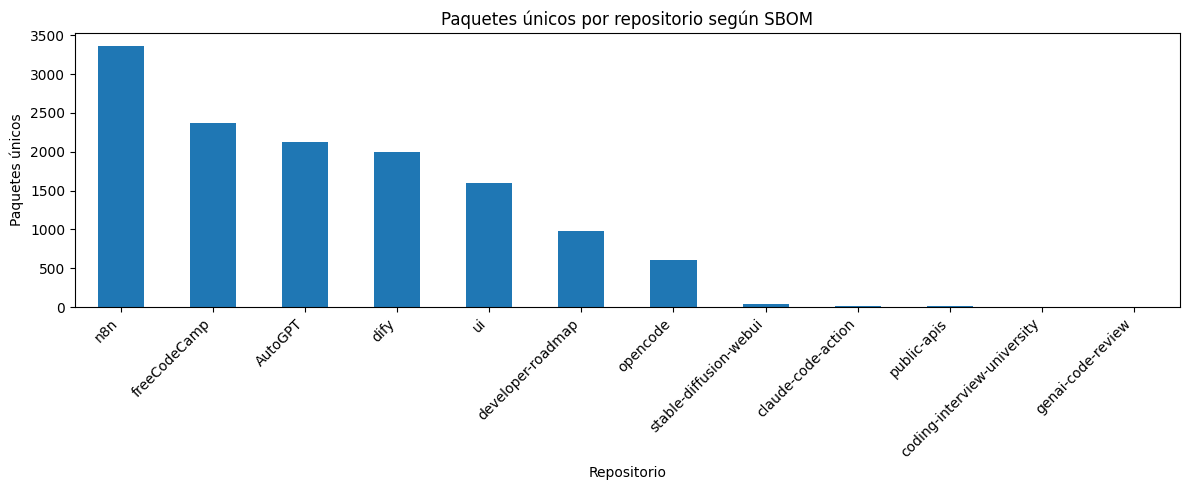

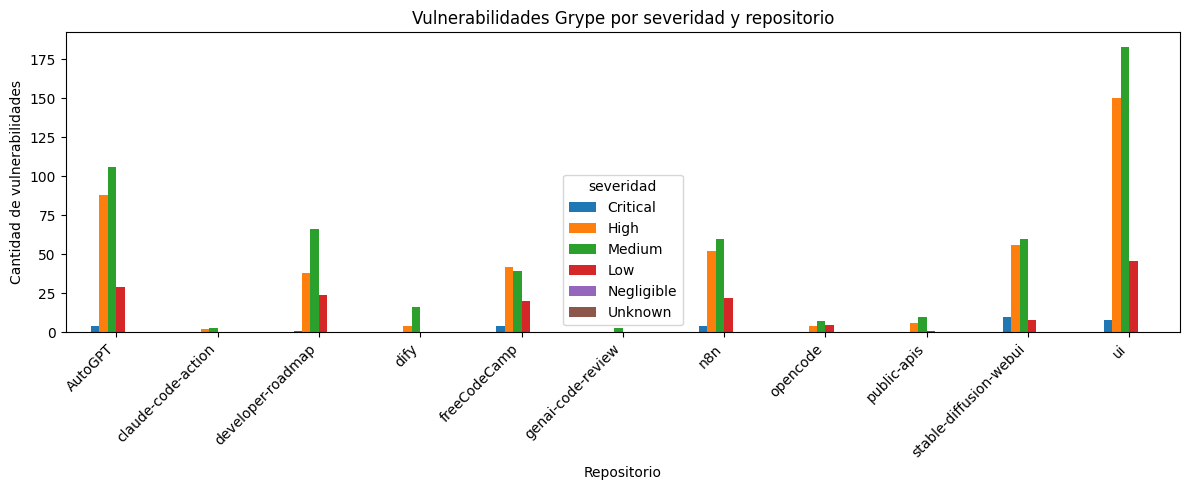

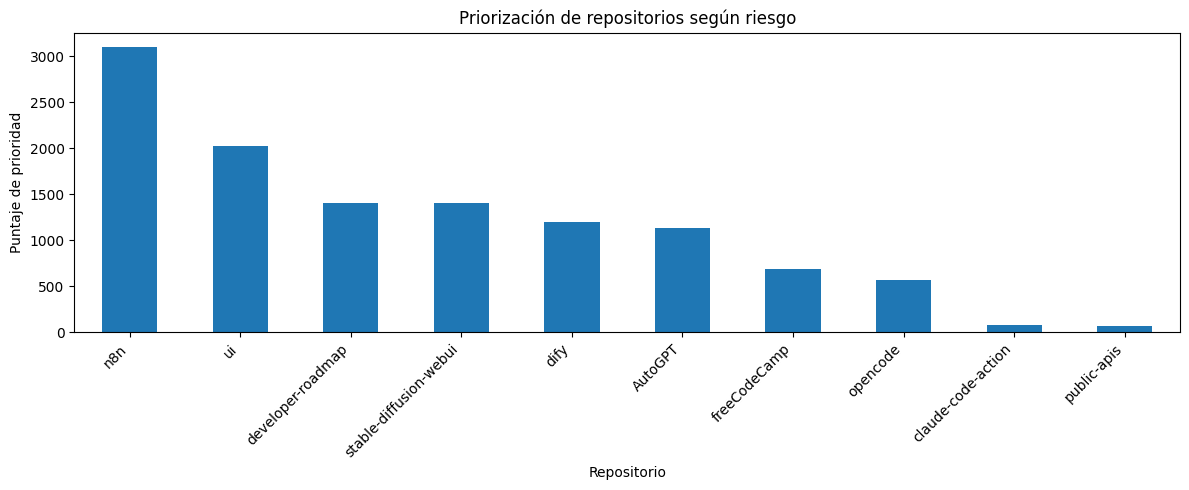

In [28]:
if not resumen_sbom.empty:
    ax = resumen_sbom.sort_values("paquetes_unicos", ascending=False).plot(
        kind="bar", x="repo", y="paquetes_unicos", figsize=(12, 5), legend=False
    )
    ax.set_title("Paquetes únicos por repositorio según SBOM")
    ax.set_xlabel("Repositorio")
    ax.set_ylabel("Paquetes únicos")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if not resumen_grype.empty:
    plot_df = resumen_grype.set_index("repo")
    cols = [c for c in severity_order if c in plot_df.columns]
    if cols:
        ax = plot_df[cols].plot(kind="bar", figsize=(12, 5))
        ax.set_title("Vulnerabilidades Grype por severidad y repositorio")
        ax.set_xlabel("Repositorio")
        ax.set_ylabel("Cantidad de vulnerabilidades")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

if "comparacion" in globals() and not comparacion.empty:
    top_prioridad = comparacion.head(10)
    ax = top_prioridad.plot(kind="bar", x="repo", y="puntaje_prioridad", figsize=(12, 5), legend=False)
    ax.set_title("Priorización de repositorios según riesgo")
    ax.set_xlabel("Repositorio")
    ax.set_ylabel("Puntaje de prioridad")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 14. Exportar tablas para el README

Esta sección guarda CSVs en `data/results/resumen/` para que puedas adjuntarlos o citarlos en el README.

In [29]:
OUT = RESULTS / "resumen"
OUT.mkdir(parents=True, exist_ok=True)

exports = {
    "resumen_sbom.csv": resumen_sbom if "resumen_sbom" in globals() else pd.DataFrame(),
    "resumen_grype.csv": resumen_grype if "resumen_grype" in globals() else pd.DataFrame(),
    "comparacion_priorizacion.csv": comparacion if "comparacion" in globals() else pd.DataFrame(),
    "top_vulnerabilidades.csv": top_vulns if "top_vulns" in globals() else pd.DataFrame(),
    "ciclo_conozco_verifico_evidencio_decido.csv": ciclo_df if "ciclo_df" in globals() else pd.DataFrame(),
    "resumen_vectores.csv": resumen_vectores if "resumen_vectores" in globals() else pd.DataFrame(),
}

for filename, df in exports.items():
    if isinstance(df, pd.DataFrame) and not df.empty:
        path = OUT / filename
        df.to_csv(path, index=False)
        print("Guardado:", path)

Guardado: /workspaces/produccion_software_emi305/data/results/resumen/resumen_sbom.csv
Guardado: /workspaces/produccion_software_emi305/data/results/resumen/resumen_grype.csv
Guardado: /workspaces/produccion_software_emi305/data/results/resumen/comparacion_priorizacion.csv
Guardado: /workspaces/produccion_software_emi305/data/results/resumen/top_vulnerabilidades.csv
Guardado: /workspaces/produccion_software_emi305/data/results/resumen/ciclo_conozco_verifico_evidencio_decido.csv
Guardado: /workspaces/produccion_software_emi305/data/results/resumen/resumen_vectores.csv


## 15. Conclusiones automáticas para adaptar al README

Estas conclusiones deben revisarse manualmente antes de entregarlas.

In [30]:
conclusiones = []

if "comparacion" in globals() and not comparacion.empty:
    conclusiones.append("Se compararon los repositorios usando SBOM para estimar superficie de dependencias y Grype para identificar vulnerabilidades en dependencias.")

    top_prioridad = comparacion.sort_values("puntaje_prioridad", ascending=False).iloc[0]
    conclusiones.append(
        f"El repositorio con mayor prioridad inicial es `{top_prioridad['repo']}`, "
        f"con puntaje de prioridad {top_prioridad['puntaje_prioridad']:.2f}, "
        f"{int(top_prioridad['vulnerabilidades_criticas_altas'])} vulnerabilidades Critical/High "
        f"y {int(top_prioridad['vulnerabilidades_grype'])} vulnerabilidades Grype en total."
    )

    top_deps = comparacion.sort_values("paquetes_unicos", ascending=False).iloc[0]
    conclusiones.append(
        f"El repositorio con mayor superficie de dependencias es `{top_deps['repo']}`, "
        f"con {int(top_deps['paquetes_unicos'])} paquetes únicos identificados en la SBOM."
    )

    if int(top_prioridad["vulnerabilidades_criticas_altas"]) > 0:
        conclusiones.append("La primera acción recomendada es atender vulnerabilidades Critical y High, validar si las versiones afectadas son usadas realmente y aplicar actualizaciones o mitigaciones.")
    else:
        conclusiones.append("No se detectaron vulnerabilidades Critical/High en la comparación consolidada, por lo que la gestión puede priorizar vulnerabilidades Medium, superficie de dependencias y endurecimiento de pipelines.")

if not grype_df.empty:
    conclusiones.append("Grype aporta evidencia sobre dependencias vulnerables, versiones instaladas y, cuando existe, versiones corregidas.")

if not sbom_df.empty:
    conclusiones.append("La SBOM permite verificar qué componentes existen en cada repositorio y sirve como base para justificar el alcance del análisis.")

if codeql_df.empty:
    conclusiones.append("No se detectaron hallazgos CodeQL/SARIF legibles con el parser usado en este notebook; esto debe indicarse como limitación o revisarse manualmente con los reportes originales.")
else:
    conclusiones.append("CodeQL/SARIF complementa el análisis de dependencias porque permite revisar hallazgos asociados al código fuente.")

for c in conclusiones:
    display(Markdown(f"- {c}"))

- Se compararon los repositorios usando SBOM para estimar superficie de dependencias y Grype para identificar vulnerabilidades en dependencias.

- El repositorio con mayor prioridad inicial es `n8n`, con puntaje de prioridad 3097.63, 56 vulnerabilidades Critical/High y 138 vulnerabilidades Grype en total.

- El repositorio con mayor superficie de dependencias es `n8n`, con 3363 paquetes únicos identificados en la SBOM.

- La primera acción recomendada es atender vulnerabilidades Critical y High, validar si las versiones afectadas son usadas realmente y aplicar actualizaciones o mitigaciones.

- Grype aporta evidencia sobre dependencias vulnerables, versiones instaladas y, cuando existe, versiones corregidas.

- La SBOM permite verificar qué componentes existen en cada repositorio y sirve como base para justificar el alcance del análisis.

- CodeQL/SARIF complementa el análisis de dependencias porque permite revisar hallazgos asociados al código fuente.

## 16. Plantilla breve para el README

Puedes usar esta estructura en el README del repositorio de entrega:

```markdown
# Propuesta de gestión de vulnerabilidades

## 1. Contexto del análisis
Se analizaron repositorios usando SBOM, Grype y CodeQL/SARIF.

## 2. Vulnerabilidades encontradas
Incluir tabla de `data/results/resumen/top_vulnerabilidades.csv`.

## 3. Clasificación según vector de ataque
Usar `data/results/resumen/resumen_vectores.csv`.

## 4. Ciclo Conozco → Verifico → Evidencio → Decido y Actúo
Usar `data/results/resumen/ciclo_conozco_verifico_evidencio_decido.csv`.

## 5. Priorización de vulnerabilidades
Usar `data/results/resumen/comparacion_priorizacion.csv`.

## 6. Acciones propuestas
Actualizar dependencias, revisar uso real, endurecer CI/CD, manejar secretos y repetir escaneos.

## 7. Evidencia utilizada
Listar SBOMs, reportes Grype, SARIF/CodeQL, logs y capturas.

## 8. Conclusiones
Explicar cómo las acciones reducen riesgo.
```